# 02 - Correlation, Covariance & Distributions

**Primary**: Priya Venugopal Nair
**Reviewed and extended by**: Naman Sudan

This notebook covers
- Pearson correlation and covariance at the order level
- Manual covariance and correlation calculations from the formula
- Chebyshev's inequality and the empirical rule applied to total spend
- Distribution fitting for total_spend (normal-curve overlay, Q-Q plot, Shapiro test)
- Customer-level aggregation as a supplementary view (not the main result)

**Course references**: Lecture 3 (Correlation, Covariance, Distribution Theorems), Lecture 7 (Probability Distributions)


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'

FIG_DIR = os.path.join('..', 'report', 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

def savefig(name):
    plt.savefig(os.path.join(FIG_DIR, name), dpi=300, bbox_inches='tight')

df = pd.read_csv('../data/starbucks_customer_ordering_patterns.csv')
print(f'rows: {len(df):,}, columns: {df.shape[1]}')


rows: 100,000, columns: 20


## 1. Order-Level Correlation and Covariance (Main Result)

We treat each row in the dataset as one order. Correlations are computed across the 100,000 orders. This is the primary level of analysis because each order is an independent observation drawn from the customer base.

The Pearson correlation coefficient (Lecture 3) is

$$r_{XY} = \frac{\mathrm{Cov}(X, Y)}{\sigma_X \, \sigma_Y}$$

with sample covariance

$$\mathrm{Cov}(X, Y) = \frac{1}{n - 1} \sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y}).$$


In [2]:
num_cols = ['total_spend', 'cart_size', 'num_customizations',
            'fulfillment_time_min', 'customer_satisfaction']

cov_matrix = df[num_cols].cov()
corr_matrix = df[num_cols].corr()

print('Covariance matrix (order level):')
print(cov_matrix.round(3))
print()
print('Pearson correlation matrix (order level):')
print(corr_matrix.round(3))


Covariance matrix (order level):
                       total_spend  cart_size  num_customizations  \
total_spend                 30.325      8.416               3.296   
cart_size                    8.416      2.883               0.238   
num_customizations           3.296      0.238               2.140   
fulfillment_time_min        -0.103     -0.020              -0.025   
customer_satisfaction        0.428      0.066               0.086   

                       fulfillment_time_min  customer_satisfaction  
total_spend                          -0.103                  0.428  
cart_size                            -0.020                  0.066  
num_customizations                   -0.025                  0.086  
fulfillment_time_min                  2.403                 -0.088  
customer_satisfaction                -0.088                  1.402  

Pearson correlation matrix (order level):
                       total_spend  cart_size  num_customizations  \
total_spend               

### Manual covariance and correlation between cart_size and total_spend

Computing the formula by hand and comparing to pandas. This verifies that the values come from the formula taught in Lecture 3, not from a black-box function.


In [3]:
x = df['cart_size'].to_numpy()
y = df['total_spend'].to_numpy()
n = len(x)

x_bar = x.mean()
y_bar = y.mean()
cov_manual = ((x - x_bar) * (y - y_bar)).sum() / (n - 1)
sd_x = np.sqrt(((x - x_bar) ** 2).sum() / (n - 1))
sd_y = np.sqrt(((y - y_bar) ** 2).sum() / (n - 1))
r_manual = cov_manual / (sd_x * sd_y)

print(f'mean cart_size  = {x_bar:.4f}')
print(f'mean total_spend = {y_bar:.4f}')
print(f'sd cart_size    = {sd_x:.4f}')
print(f'sd total_spend  = {sd_y:.4f}')
print(f'Cov(cart_size, total_spend) manual : {cov_manual:.4f}')
print(f'Cov pandas                         : {df[["cart_size","total_spend"]].cov().iloc[0,1]:.4f}')
print(f'Pearson r manual                   : {r_manual:.4f}')
print(f'Pearson r pandas                   : {df[["cart_size","total_spend"]].corr().iloc[0,1]:.4f}')


mean cart_size  = 3.7415
mean total_spend = 14.8668
sd cart_size    = 1.6978
sd total_spend  = 5.5068
Cov(cart_size, total_spend) manual : 8.4159
Cov pandas                         : 8.4159
Pearson r manual                   : 0.9001
Pearson r pandas                   : 0.9001


### Visualizing the order-level correlation matrix


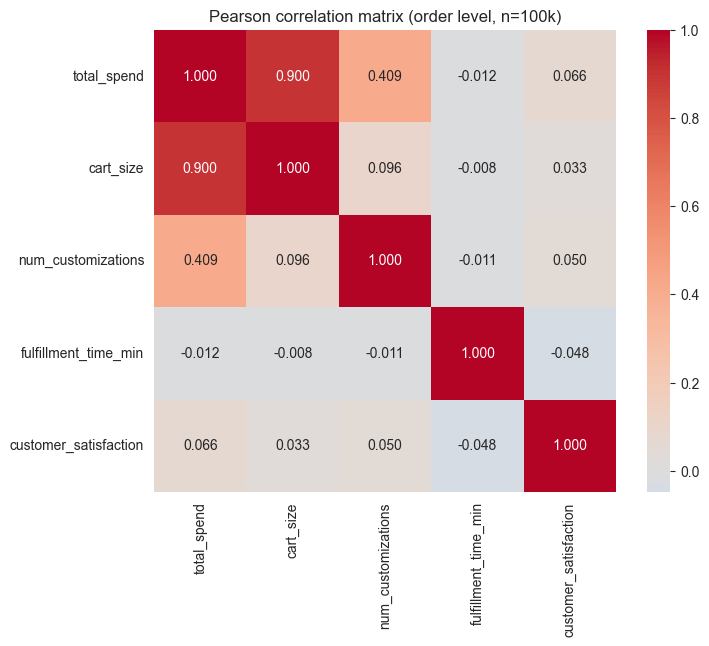

In [4]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f', square=True)
plt.title('Pearson correlation matrix (order level, n=100k)')
savefig('02_corr_heatmap_order_level.png')
plt.show()


### Scatter plots: predictors vs total_spend


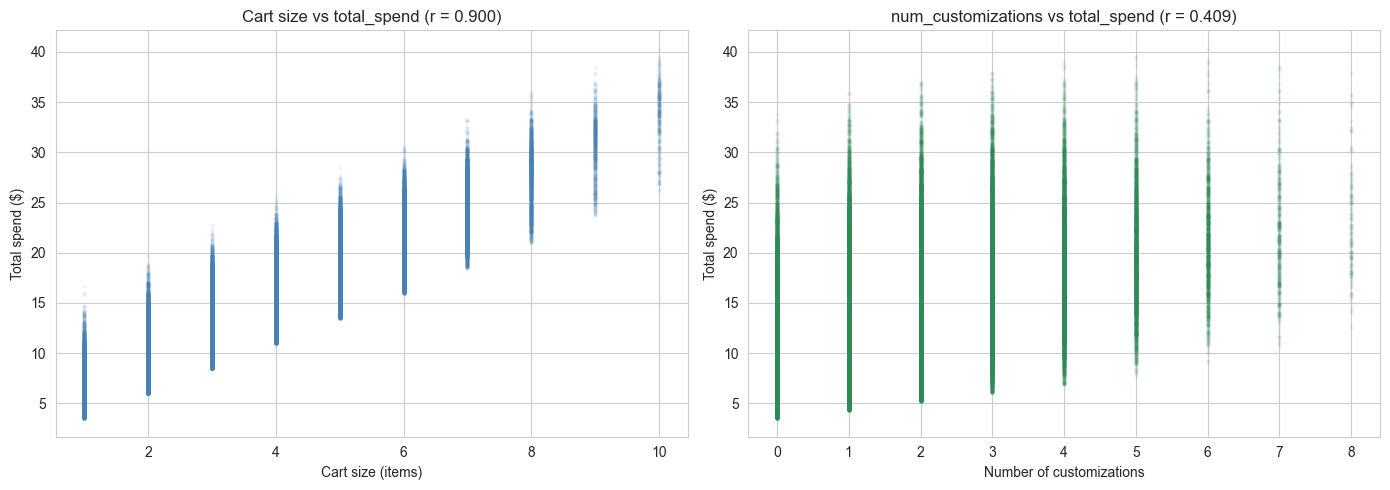

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['cart_size'], df['total_spend'], alpha=0.05, s=5, color='steelblue')
axes[0].set_xlabel('Cart size (items)')
axes[0].set_ylabel('Total spend ($)')
r1 = corr_matrix.loc['cart_size', 'total_spend']
axes[0].set_title(f'Cart size vs total_spend (r = {r1:.3f})')

axes[1].scatter(df['num_customizations'], df['total_spend'], alpha=0.05, s=5, color='seagreen')
axes[1].set_xlabel('Number of customizations')
axes[1].set_ylabel('Total spend ($)')
r2 = corr_matrix.loc['num_customizations', 'total_spend']
axes[1].set_title(f'num_customizations vs total_spend (r = {r2:.3f})')

plt.tight_layout()
savefig('02_scatter_predictors_vs_spend.png')
plt.show()


**Interpretation.** Cart size is the dominant order-level driver of total spend with a very strong positive correlation ($r \approx 0.90$). num_customizations is a weaker secondary driver ($r \approx 0.41$). Fulfillment time and customer satisfaction are essentially uncorrelated with spend at the order level (|r| < 0.07). These values are reported in the final discussion.


## 2. Chebyshev's Inequality and the Empirical Rule

Chebyshev's inequality (Lecture 3) states that for any distribution with finite mean and variance, the proportion of observations within $k$ standard deviations of the mean is at least

$$P(|X - \mu| < k\sigma) \;\ge\; 1 - \frac{1}{k^2}.$$

For comparison, the empirical (68 / 95 / 99.7) rule applies only when $X$ is approximately normal.


In [6]:
spend = df['total_spend']
mu = spend.mean()
sd = spend.std()

rows = []
for k in [2, 3]:
    low, high = mu - k * sd, mu + k * sd
    actual = ((spend >= low) & (spend <= high)).mean() * 100
    cheb = (1 - 1 / k ** 2) * 100
    emp = {2: 95.4, 3: 99.7}[k]
    rows.append([k, low, high, actual, cheb, emp])

cheb_df = pd.DataFrame(rows, columns=['k', 'lower', 'upper',
                                      'actual_%', 'chebyshev_min_%', 'empirical_rule_%'])
print(f'mean total_spend = ${mu:.2f}, sd = ${sd:.2f}')
print(cheb_df.round(2).to_string(index=False))


mean total_spend = $14.87, sd = $5.51
 k  lower  upper  actual_%  chebyshev_min_%  empirical_rule_%
 2   3.85  25.88     95.83            75.00              95.4
 3  -1.65  31.39     99.34            88.89              99.7


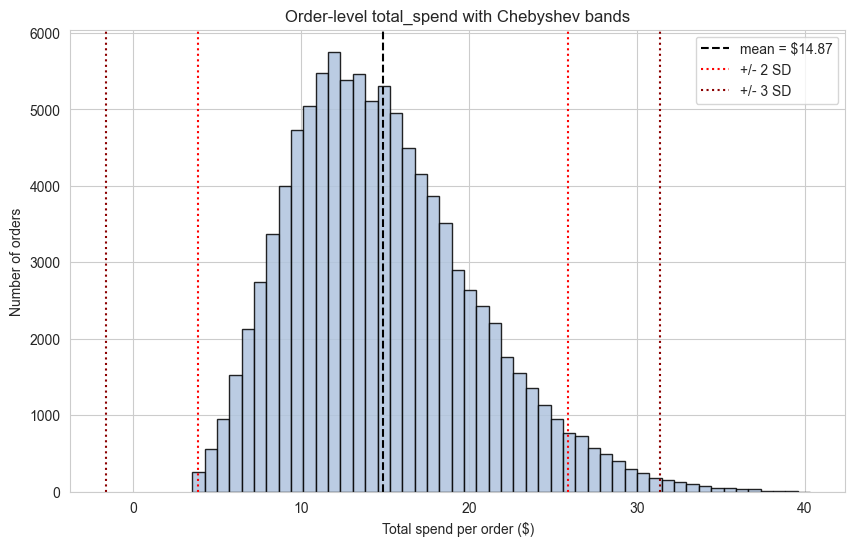

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(spend, bins=50, color='lightsteelblue', edgecolor='black', alpha=0.85)
ax.axvline(mu, color='black', linestyle='--', label=f'mean = ${mu:.2f}')
ax.axvline(mu - 2 * sd, color='red', linestyle=':', label='+/- 2 SD')
ax.axvline(mu + 2 * sd, color='red', linestyle=':')
ax.axvline(mu - 3 * sd, color='darkred', linestyle=':', label='+/- 3 SD')
ax.axvline(mu + 3 * sd, color='darkred', linestyle=':')
ax.set_xlabel('Total spend per order ($)')
ax.set_ylabel('Number of orders')
ax.set_title('Order-level total_spend with Chebyshev bands')
ax.legend()
savefig('02_chebyshev_bands.png')
plt.show()


**Interpretation.** Chebyshev guarantees only 75% within 2 SDs and 88.9% within 3 SDs. The actual share is much higher because the distribution is closer to normal than the worst case. The empirical rule values (95.4% and 99.7%) are tighter, but they assume normality, which is checked next.


## 3. Is total_spend Normally Distributed?

Three pieces of evidence are stacked: the histogram with a normal-density overlay, a Q-Q plot, and a formal normality test (Shapiro on a random subsample because Shapiro on $n=100\text{k}$ is unstable in scipy).


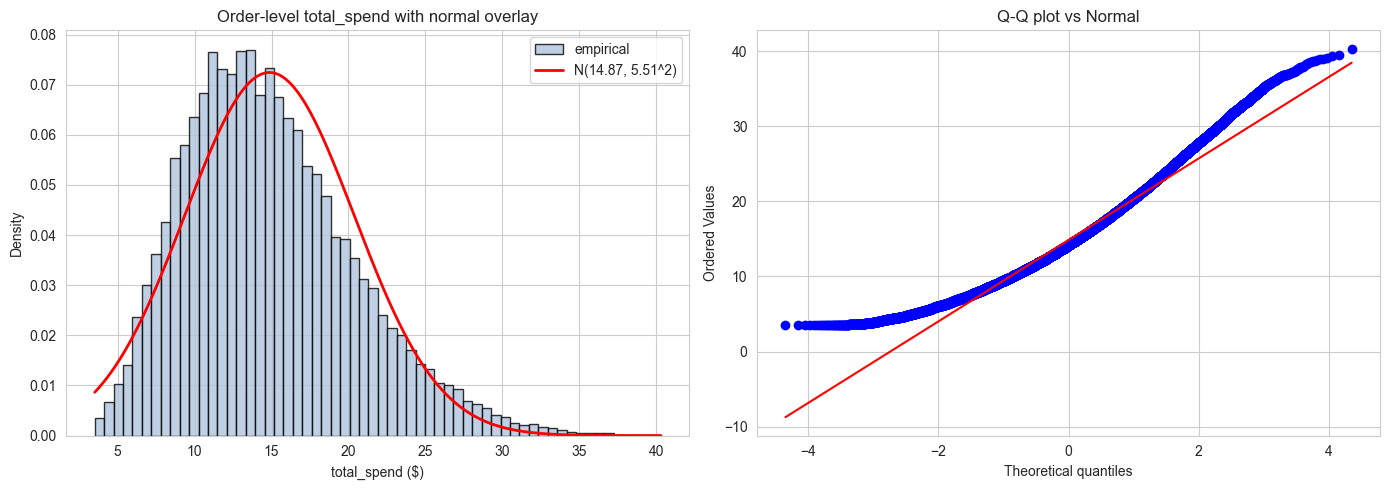

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with normal overlay
axes[0].hist(spend, bins=60, density=True, color='lightsteelblue',
             edgecolor='black', alpha=0.8, label='empirical')
xs = np.linspace(spend.min(), spend.max(), 400)
axes[0].plot(xs, stats.norm.pdf(xs, mu, sd), color='red', lw=2,
             label=f'N({mu:.2f}, {sd:.2f}^2)')
axes[0].set_xlabel('total_spend ($)')
axes[0].set_ylabel('Density')
axes[0].set_title('Order-level total_spend with normal overlay')
axes[0].legend()

# Q-Q plot
stats.probplot(spend, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q plot vs Normal')

plt.tight_layout()
savefig('02_normal_fit.png')
plt.show()


In [9]:
# Skewness and kurtosis for total_spend
from scipy.stats import skew, kurtosis, shapiro

print(f'Skewness                    : {skew(spend):.4f}')
print(f'Excess kurtosis             : {kurtosis(spend):.4f}')

# Shapiro on a random subsample of 5,000 (full 100k is not advised)
sample = spend.sample(5000, random_state=0)
W, p = shapiro(sample)
print(f'Shapiro W (n=5000)          : W = {W:.4f}, p-value = {p:.6g}')


Skewness                    : 0.6701
Excess kurtosis             : 0.3775
Shapiro W (n=5000)          : W = 0.9734, p-value = 1.59286e-29


**Interpretation.** total_spend is moderately right-skewed (skewness $\approx 0.67$), with mild positive excess kurtosis ($\approx 0.38$). The histogram is bell-shaped on the left but has a longer right tail, and the Q-Q plot bends upward in the upper tail. The Shapiro test rejects strict normality, which is expected given the skew. We treat total_spend as approximately normal in the body of the distribution but not in the upper tail. This matters for Notebook 04: empirical probabilities are preferred over normal-CDF approximations for tail events.


## 4. Customer-Level View (Supplementary Only)

Aggregating the 100k orders into ~15k customers lets us look at total customer spend. **Caveat:** correlations between sums (e.g. `total_spend_per_customer` vs `total_customizations_per_customer`) inflate because both sums grow with the customer's order count. The order-level view in section 1 is the main result. The customer-level view is shown only to document the inflation.


In [10]:
customer = df.groupby('customer_id').agg(
    n_orders=('order_id', 'count'),
    total_spend=('total_spend', 'sum'),
    avg_cart_size=('cart_size', 'mean'),
    total_customs=('num_customizations', 'sum'),
).reset_index()

cust_corr = customer[['n_orders', 'total_spend', 'avg_cart_size', 'total_customs']].corr()
print('Customer-level correlation (sum-of-sums artifact present):')
print(cust_corr.round(3))


Customer-level correlation (sum-of-sums artifact present):
               n_orders  total_spend  avg_cart_size  total_customs
n_orders          1.000        0.928         -0.000          0.753
total_spend       0.928        1.000          0.298          0.813
avg_cart_size    -0.000        0.298          1.000          0.076
total_customs     0.753        0.813          0.076          1.000


In [11]:
# Side-by-side comparison highlighting the inflation
order_r = df[['cart_size', 'num_customizations', 'total_spend']].corr().loc[
    ['cart_size', 'num_customizations'], 'total_spend']
cust_r = cust_corr.loc[['avg_cart_size', 'total_customs'], 'total_spend']
print('Pearson r with total_spend')
print(f'  order level   cart_size           : {order_r["cart_size"]:.3f}')
print(f'  order level   num_customizations  : {order_r["num_customizations"]:.3f}')
print(f'  customer level avg_cart_size      : {cust_r["avg_cart_size"]:.3f}')
print(f'  customer level total_customs      : {cust_r["total_customs"]:.3f}')


Pearson r with total_spend
  order level   cart_size           : 0.900
  order level   num_customizations  : 0.409
  customer level avg_cart_size      : 0.298
  customer level total_customs      : 0.813


**Why customer-level numbers move.** Two effects in opposite directions appear when we move from order level to customer level:

- `total_customs` is a *sum* over a customer's orders. A customer with more orders has both a higher `total_spend` and a higher `total_customs` simply because both grow with the number of orders. This drags the correlation up from $r = 0.41$ at the order level to $r = 0.81$ at the customer level. This is a sum-of-sums artifact, not a stronger underlying relationship.
- `avg_cart_size` is an *average* per order. Averaging removes most of the order-count signal, so the cart_size relationship that was very strong at the order level ($r = 0.90$) shrinks to $r = 0.30$ at the customer level. Two customers can have the same average cart_size but very different total spend, depending on how often they order.

The order-level correlations from Section 1 are the right values to report in the final paper. The customer-level numbers are useful only for documenting these aggregation effects.


## 5. Key Observations

- At the order level, cart_size is the dominant driver of total_spend ($r \approx 0.90$). num_customizations is a weaker secondary driver ($r \approx 0.41$). Fulfillment time and customer satisfaction are uncorrelated with spend.
- The actual proportion of total_spend within 2 SDs of the mean is about 95.8%, comfortably above Chebyshev's worst-case bound of 75% and very close to the 95.4% expected under exact normality.
- total_spend is moderately right-skewed (skew $\approx 0.67$) with mild positive kurtosis. It is approximately normal in the body of the distribution but the right tail is heavier than normal. Shapiro rejects strict normality at $n = 5000$.
- Customer-level aggregation distorts the relationships in two opposite ways: summing customizations inflates correlation ($0.41 \to 0.81$), and averaging cart_size deflates it ($0.90 \to 0.30$). Order-level correlations are reported as the main result.
- These findings frame the rest of the project: t-tests in Notebook 03 are reasonable given approximate normality in the body, and tail probabilities in Notebook 04 should be computed empirically rather than from a normal CDF.
